# **BÀI TẬP 3 - THỐNG KÊ MÁY TÍNH VÀ ỨNG DỤNG**

---

### **Thông tin sinh viên**
- **Họ tên:** Lý Liên Hoa

- **MSSV:** 22127117 

---

#### Thư viện

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

np.random.seed(42)

---

## **Câu 1.**

Cặp biến ngẫu nhiên X, Y có hàm mật độ xác suất đồng thời

$$ f(x,y) \propto e^{-\frac{x^2y^2 + x^2 + y^2 - 8x - 8y}{2}} $$

a. Thiết kế thuật toán lấy mẫu cho $(X, Y)$ bằng các phương pháp:
1. Lấy mẫu độc lập,
2. Metropolis-Hastings (hoặc Metropolis),
3. Lấy mẫu Gibbs.

b. So sánh các phương pháp ở Câu (a).

c. Chọn phương pháp tốt nhất ở Câu (a) để ước lượng xác suất $P(X \geq Y)$ và kỳ vọng $E(XY)$ (có đánh giá sai số).


---

### **a. Thiết kế thuật toán lấy mẫu cho ($X, Y$) bằng phương pháp**

In [2]:
def f(x, y):
    x_squared = x**2
    y_squared = y**2
    return np.exp(-(x_squared * y_squared + x_squared + y_squared - 8 * x - 8 * y) / 2)

#### **1. Lấy mẫu độc lập**

Vì hàm mật độ xác suất đồng thời $ f(x,y) \propto e^{-\frac{x^2y^2 + x^2 + y^2 - 8x - 8y}{2}} $ phức tạp, khó có thể tách ra thành 2 hàm chỉ phụ thuộc vào $x$ và $y$. Thế nên, để lấy mẫu độc lập ta có thể dùng phương pháp **Basic Rejection Sampling (BRS)** để tạo ra các giá trị mẫu từ một phân phối mục tiêu với hàm mật độ xác xuất $f(x, y)$ bằng cách sử dụng một phân phối đề xuất (proposal density) g(x, y) dễ lấy mẫu hơn.

Giả sử: 
$$
g(x, y) = g_1(x)\,g_2(y) = x^2y^2 + x^2 + y^2 - 8x - 8y
$$

Với $g_1(x)$ và $g_2(y)$ đều tuân theo phân phối chuẩn $\mathcal{N}(\mu, \sigma^2)$

Theo lý thuyết, ta cần tìm hằng số $M$ sao cho với mọi $(x, y)$:
$$
f(x, y) \le M g(x, y)
$$

Ta biết, một biến ngẫu nhiên $X$ tuân theo phân phối Gaussian được kí hiệu $X \sim \mathcal{N}(\mu, \sigma^2)$, trong đó $\mu$, $\sigma$ là hai tham số đặc trưng của phân phối Gaussian. Phân phối Gaussian có hình dạng là một quả chuông mà giá trị xác suất lớn nhất tại $x = \mu$ hình dạng của phân phối đối xứng qua $\mu$. Do đó ta cần tìm $(x, y)$ sao cho $f(x, y)$ đạt cực đại tại điểm đó.

$f(x, y)$ đạt cực đại khi $g(x, y)$ đạt cực tiểu.

Lấy $\ln$ của $f(x, y)$ ta được:
$$
L(x, y) = \ln(f(x, y)) = -\frac{x^2y^2 + x^2 + y^2 - 8x - 8y}{2} = -\frac{1}{2} g(x, y)
$$

Ta có:
$$
\begin{cases}
\frac{\partial g}{\partial x} = 2x(y^2 + 1) - 8 = 0, \\
\frac{\partial g}{\partial y} = 2y(x^2 + 1) - 8 = 0.
\end{cases}
\Rightarrow
\begin{cases}
x(y^2 + 1) = 4 & (1) \\
y(x^2 + 1) = 4 & (2)
\end{cases}
$$



Lấy $(1) - (2)$ ta được:
$$
\begin{align*}
&x(y^2 + 1) - y(x^2 + 1) = 0 \\

&\Rightarrow  
xy^2 + x - x^2y - y = 0 \\

&\Rightarrow
xy(y - x) - (y - x) = 0 \\

&\Rightarrow
(y - x)(xy - 1) = 0 \\

&\Rightarrow
\left[
\begin{array}{l}
x = y \\
xy = 1, \quad x \ne y \ne 0
\end{array}
\right.

\end{align*}
$$

- Nếu $x = y$, ta suy ra được điểm cực trị của $g(x, y)$ thõa $g'(x, y) = 0$ với $g(x, y) = x^4 + 2x^2 - 16x$:

$$
\Rightarrow \;
g'(x, y) = 4x^3 + 4x -16 = 0
$$

$\quad\quad \Rightarrow g'(x, y)$ có nghiệm duy nhất $x_0 = y_0 \approx 1.38$.  
$\quad\quad \Rightarrow g(x, y)$ đạt cực tiểu tại $(1.38, 1.38)$  
$\quad\quad \Rightarrow f(x, y)$ đạt cực đại tại $(1.38, 1.38)$

Lúc này, $f(x, y) \approx 1513.58$

- Nếu $xy = 1$ hay $y = \frac{1}{x}$, thế vào $(1)$ ta được:

$$
\begin{align*}
&\Rightarrow x (\frac{1}{x^2} + 1) = 4 \\

&\Rightarrow \frac{1}{x} + x = 4 \\

&\Rightarrow x^2 - 4x + 1 = 0 \\

&\Rightarrow
\left[
\begin{array}{l}
x = 2 + \sqrt{3} \\
x = 2 - \sqrt{3}
\end{array}
\right. \\ \\

\end{align*}
$$



Do đó, với:

- $x_1 = 2 + \sqrt{3} \approx 3.732,\quad y_1 = \frac{1}{x_1} = 2 - \sqrt{3} \approx 0.268.$
- $x_2 = 2 - \sqrt{3} \approx 0.268,\quad y_2 = \frac{1}{x_2} = 2 + \sqrt{3}\approx 3.732.$

Hơn nữa, hàm $f(x, y)$ có tính đối xứng nên $f(x, y) = f(y, x)$. Điều này có nghĩa là nếu $(x_0, y_0)$ là điểm cực trị, thì $(y_0, x_0)$ cũng là điểm cực trị. Nếu có hai cực trị khác nhau (cực đại hoặc cực tiểu), thì chúng phải xuất hiện theo cặp đối xứng.

Lúc này, giá trị $f(x_1, y_1) = f(x_2, y_2) \approx 4914.77$


Tóm lại, hệ đạo hàm riêng có 3 nghiệm thực: $(1.38, 1.38), (2 + \sqrt{3}, 2 - \sqrt{3}), (2 - \sqrt{3}, 2 + \sqrt{3})$

vói giá trị $f(x_1. y_1)$ lớn hơn hẳn $f(x_0, y_0)$

Suy ra, phân phối có 2 đỉnh cực đại tại $(2 + \sqrt{3}, 2 - \sqrt{3}), (2 - \sqrt{3}, 2 + \sqrt{3})$

Phân phối mục tiêu $f$ trong bài có **hai đỉnh** (modes) ở:

$$
(2 + \sqrt{3},\ 2 - \sqrt{3}) \quad \text{và} \quad (2 - \sqrt{3},\ 2 + \sqrt{3}).
$$

Nếu ta dùng **một** phân phối Gaussian duy nhất làm đề xuất:

- Hoặc ta đặt tâm $\mu$ gần một trong hai đỉnh  
  $\rightarrow$ Phân phối đề xuất sẽ "bỏ sót" vùng đỉnh còn lại  
  $\rightarrow$ Để phủ hết, $\sigma$ phải rất lớn  
  $\rightarrow$ Dẫn đến $M$ phải rất lớn  
  $\rightarrow$ **Tỷ lệ chấp nhận thấp**.

- Hoặc ta đặt $\mu$ ở giữa hai đỉnh  
  $\rightarrow$ Vẫn phải tăng $\sigma$ đủ lớn để phủ cả hai vùng đỉnh  
  $\rightarrow$ Dẫn đến $M$ lớn, nhiều mẫu bị từ chối.


Khi phân phối có nhiều đỉnh, **mixture** (hỗn hợp) nhiều Gaussian, mỗi Gaussian đặt quanh một đỉnh, thường cho tỷ lệ chấp nhận cao hơn. Trong ví dụ, ta chọn:

$$
g(x, y) = 0.5 \cdot \mathcal{N}(\text{mode}_1, \sigma^2 I)
+ 0.5 \cdot \mathcal{N}(\text{mode}_2, \sigma^2 I)
$$

với:

$$
\text{mode}_1 = (2 + \sqrt{3},\ 2 - \sqrt{3}) \quad \text{và} \quad
\text{mode}_2 = (2 - \sqrt{3},\ 2 + \sqrt{3}).
$$


Ta chọn trọng số $0.5 - 0.5$ vì $f(x, y)$ có tính đối xứng.

In [3]:
def estimate_M(f, g_pdf, g_sample, n_samples=100000, safety_factor=1.2):
    """
    f(x, y): hàm mật độ mục tiêu.
    g_pdf(x, y): hàm mật độ của phân phối đề xuất.
    g_sample(): hàm sinh 1 mẫu (x, y) từ đề xuất q.
    n_samples: số mẫu để ước lượng.
    safety_factor: hệ số an toàn, thường > 1.
    
    Trả về M ~ safety_factor * max_{i} [ f(x_i, y_i) / q(x_i, y_i) ].
    """
    ratios = []
    for _ in range(n_samples):
        x_prop, y_prop = g_sample()
        val = f(x_prop, y_prop) / g_pdf(x_prop, y_prop)
        ratios.append(val)
    M_est = max(ratios)
    return safety_factor * M_est

mode1 = (2+np.sqrt(3), 2-np.sqrt(3))
mode2 = (2-np.sqrt(3), 2+np.sqrt(3))  

# Ví dụ 
sigma = 0.8

def g_sample():
    if np.random.rand() < 0.5:
        m = mode1
    else:
        m = mode2
    return np.random.normal(m, sigma) 

def gauss2d(x, y, mu_x, mu_y, s):
    # Ta chọn trường hợp đặc biệt p = 0, sigma_x = sigma_y = s
    return (1/(2*np.pi*s**2))*np.exp(-0.5*(((x-mu_x)**2 + (y-mu_y)**2)/(s**2)))

def g_pdf(x, y):
    return 0.5*gauss2d(x, y, mode1[0], mode1[1], sigma) \
         + 0.5*gauss2d(x, y, mode2[0], mode2[1], sigma)

In [4]:
N = 10000
independent_samples = []
n_trials = 0
M = estimate_M(f, g_pdf, g_sample, n_samples=N, safety_factor=1.2)

while len(independent_samples) < N:
    n_trials += 1
    x_prop, y_prop = g_sample()
    # Tính alpha
    alpha = f(x_prop, y_prop) / (M * g_pdf(x_prop, y_prop))
    u = np.random.rand()
    if u < alpha:
        independent_samples.append([x_prop, y_prop])

independent_samples = np.array(independent_samples)
print("Số mẫu =", N, "; Số lần thử =", n_trials, "; Tỷ lệ chấp nhận: ", N/n_trials)

Số mẫu = 10000 ; Số lần thử = 865635 ; Tỷ lệ chấp nhận:  0.01155221311522755


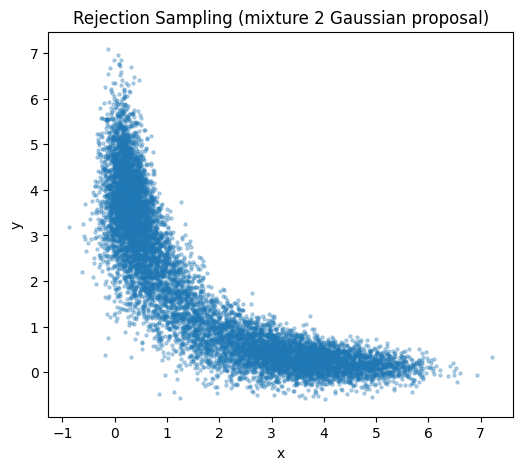

In [5]:
plt.figure(figsize=(6,5))
plt.scatter(independent_samples[:,0], independent_samples[:,1], s=5, alpha=0.3)
plt.title("Rejection Sampling (mixture 2 Gaussian proposal)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

#### 2. Lấy mẫu theo phương pháp Metropolis-Hastings (hoặc Metropolis)


In [6]:
def metropolis_sampling(N, init, proposal_sigma, burn_in=0):
    total_samples = N + burn_in
    samples = np.zeros((total_samples, 2))
    samples[0, :] = init

    for i in range(1, total_samples):
        current = samples[i-1, :]
        # Sinh đề xuất theo random-walk: (x', y') = (x, y) + N(0, proposal_sigma^2 I)
        proposal = current + np.random.normal(0, proposal_sigma, size=2)
        # Tính tỉ số chấp nhận
        ratio = f(proposal[0], proposal[1]) / f(current[0], current[1])
        alpha = min(1.0, ratio)
        if np.random.rand() < alpha:
            samples[i, :] = proposal
        else:
            samples[i, :] = current

    return samples[burn_in:]

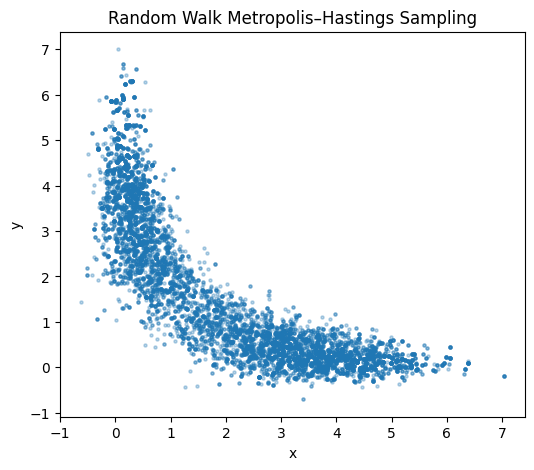

In [7]:
init = [0.0, 0.0]      
proposal_sigma = 1.0 # Độ lệch chuẩn
burn_in = 2000

metropolis_samples = metropolis_sampling(N, init, proposal_sigma, burn_in)

plt.figure(figsize=(6,5))
plt.scatter(metropolis_samples[:, 0], metropolis_samples[:, 1], s=5, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Random Walk Metropolis–Hastings Sampling")
plt.show()

#### 3. Lấy mẫu Gibbs

Ta có:
$$
f(x, y) \propto \exp\left\{ -\frac{x^2 y^2 + x^2 + y^2 - 8x - 8y}{2} \right\}
$$

Khi cố định $y$, ta có phân phối điều kiện của $x$:

$$
f(x|y) \propto \exp\left\{ -\frac{x^2 y^2 + x^2 - 8x}{2} \right\} \\ \\
$$

$$
\begin{align*}
&\Rightarrow
h(x) = x^2 y^2 + x^2 - 8x = (y^2 + 1)x^2 - 8x. \\

&\Rightarrow
h(x) = (y^2 + 1)\left[ x^2 - \frac{8}{y^2 + 1}x \right] \\


&\Rightarrow
h(x) = (y^2 + 1) \left[ \left( x - \frac{4}{y^2 + 1} \right)^2 - \left( \frac{4}{y^2 + 1} \right)^2 \right]
\end{align*}
$$

Do hằng số $\left( \frac{4}{y^2 + 1} \right)^2$ không phụ thuộc vào $x$ có thể bỏ qua trong phân phối điều kiện, nên ta có:

$$
f(x|y) \propto \exp\left\{ -\frac{(y^2 + 1)}{2} \left( x - \frac{4}{y^2 + 1} \right)^2 \right\}
$$


Nhận thấy đây là dạng của phân phối chuẩn với:

- **Trung bình:** $\mu_x = \dfrac{4}{y^2 + 1}$
- **Phương sai:** $\sigma_x^2 = \dfrac{1}{y^2 + 1}$


Tương tự với $f(y|x)$:

- **Trung bình:** $\mu_y = \dfrac{4}{x^2 + 1}$
- **Phương sai:** $\sigma_y^2 = \dfrac{1}{x^2 + 1}$

In [8]:
def gibbs_sampling(N, init, burn_in=0):
    total_samples = N + burn_in
    samples = np.zeros((total_samples, 2))
    samples[0, :] = init

    for i in range(1, total_samples):
        x_prev, y_prev = samples[i-1]
        
        # Cập nhật x từ phân phối điều kiện x|y
        var_x = 1.0 / (y_prev**2 + 1.0)
        mean_x = 4.0 / (y_prev**2 + 1.0)
        x_new = np.random.normal(mean_x, np.sqrt(var_x))
        
        # Cập nhật y từ phân phối điều kiện y|x
        var_y = 1.0 / (x_new**2 + 1.0)
        mean_y = 4.0 / (x_new**2 + 1.0)
        y_new = np.random.normal(mean_y, np.sqrt(var_y))
        
        samples[i, :] = [x_new, y_new]
        
    return samples[burn_in:]


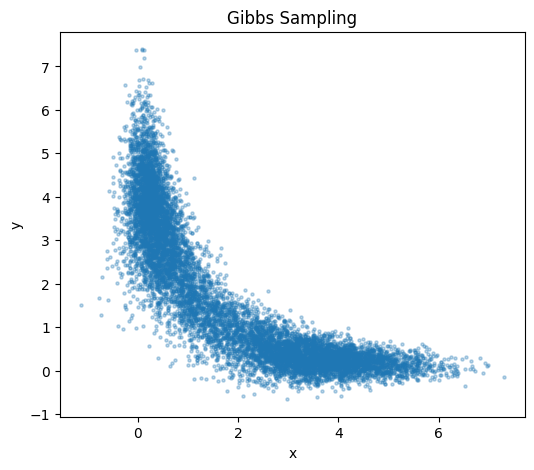

In [9]:
gibbs_samples = gibbs_sampling(N, init, burn_in)

plt.figure(figsize=(6,5))
plt.scatter(gibbs_samples[:, 0], gibbs_samples[:, 1], s=5, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gibbs Sampling")
plt.show()

### **b. So sánh các phương pháp ở Câu (a)**

| Phương pháp lấy mẫu     | Ưu điểm                                                                                                                                       | Nhược điểm                                                                                                                                                                   |
|:------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Độc lập                 | - Mẫu thu được là mẫu độc lập.                                                                                                                | - Hàm mật độ mục tiêu đa đỉnh (multi-modal) với 2 mode nên việc chọn hàm đề xuất phù hợp rất khó. <br> - Tỷ lệ chấp thuận thấp.                                             |
| Metropolis-Hastings     | - Dễ cài đặt. <br> - Với đề xuất là Random Walk, dễ dàng điều chỉnh tham số để có tỷ lệ chấp nhận hợp lý.                                     | - Các mẫu có tính phụ thuộc. <br> - Việc chọn tham số đề xuất quá lớn hoặc quá nhỏ ảnh hưởng mạnh đến khả năng “di chuyển” của chuỗi.                                      |
| Gibbs Sampling          | - Các phân phối điều kiện p(x\|y) và p(y\|x) đều có dạng chuẩn nên việc lấy mẫu rất dễ thực hiện. <br> - Hội tụ nhanh, mức độ tương quan thấp. | - Phương pháp chỉ áp dụng được khi ta có thể rút ra được phân phối điều kiện dễ lấy mẫu. <br> - Nếu không, việc áp dụng Gibbs Sampling gặp nhiều khó khăn.                |


### **c. Chọn phương pháp tốt nhất ở Câu (a) để ước lượng xác suất $P(X \geq Y)$ và kỳ vọng $E(XY)$ (có đánh giá sai số).**

Trong bài toán này, do ta có thể rút ra được dạng phân phối điều kiện chính xác cho $(x|y)$ và $(y|x)$, từ đó ta thấy **phương pháp lấy mẫu Gibbs** có tính hiệu quả cao và dễ cài đặt. Do đó, có thể xem **phương pháp lấy mẫu Gibbs** là phương pháp tốt nhất ở bài này.

In [10]:
X = gibbs_samples[:, 0]
Y = gibbs_samples[:, 1]

indicator = (X >= Y)
P_est = np.mean(indicator)
std_error_P = np.std(indicator) / np.sqrt(len(indicator))

XY = X * Y
E_XY = np.mean(XY)
std_error_E = np.std(XY) / np.sqrt(len(XY))

print("Ước lượng P(X>=Y): {:.4f} ± {:.4f}".format(P_est, std_error_P))
print("Ước lượng E(XY): {:.4f} ± {:.4f}".format(E_XY, std_error_E))

Ước lượng P(X>=Y): 0.5253 ± 0.0050
Ước lượng E(XY): 1.1261 ± 0.0096


---

## **Câu 2.**

Một đồng xu có xác suất ra ngửa là $p$. Tung đồng xu $10$ lần thì thấy $8$ lần ra ngửa. Dùng suy diễn Bayes với lần lượt các thông tin tiên nghiệm sau  
a. Không biết thông tin gì cả.  
b. Đồng xu có khả năng cân đối cao ($p$ quanh $0.5$).  
c. Đồng xu có khả năng mất cân đối cao ($p$ quanh $0$ hoặc $1$).  
d. $p$ chỉ có thể nhận 1 trong 3 giá trị: $0.2, 0.7, 0.9$.  
e. $0.4 \le 𝑝 \le 0.9$.  

Để trả lời các câu hỏi:
- (1) Giá trị của 𝑝 là bao nhiêu?
- (2) 𝑝 có lớn hơn 0.6 hay không?

---

Một đồng xu có xác suất ngửa là $p \; (0 \le p \le 1)$, và kết quả $Y$ của mỗi lần tung đồng xu là kết quả của một phép thử $Bernoulli$, $Y \sim Bernoulli(p)$

Do đó, với $D = \{y_1, y_2, y_3, ..., y_{10} \}$ và $z = \sum_{i = 1}^{10}y_i = 8$, thì hàm hợp lý của $p$ theo $D$:
$$
P(D | p) = C_{10}^8 \, p^8 \, (1 - p)^2
$$

Ta có thể viết:
$$
P(D | p) \propto p^8 \, (1 - p)^2
$$

### **a. Không biết thông tin gì cả**

Vì **thông tin tiên nghiệm là "Không biết thông tin gì cả"** về $p$, ta sẽ giả sử tất cả các giá trị $p$ trên khoảng $[0, 1]$ đều có khả năng xảy ra như nhau hay phân phối đều trên khoảng $[0, 1]$, tương đương với phân phối $\mathcal{B}(1, 1)$, ký hiệu: $p \sim \mathcal{Beta(1, 1)}$. Ta có:
$$
\begin{align*}

&P(p; a, b) \propto p^{a - 1} \; (1 - p)^{b - 1}, \quad 0 \le p \le 1 \\

\Rightarrow \;
&P(p; a, b) \propto p^0 \; (1 - p)^0 = 1
\end{align*}
$$

Từ công thức Bayes, $p$ có **phân phối hậu nghiệm** sau khi quan sát dữ liệu $D$ là:
$$
\begin{align*}
P(p | D) &\propto P(D | p) \; P(p; a, b) \\

& \propto  p^8 \, (1 - p)^2 \times 1 = p^8 \, (1 - p)^2

\end{align*}
$$

Nhận xét, $(p, D) \sim Beta(a + z, b + n - z)$

$\Rightarrow$ Phân phối hậu nghiệm: $(p, D) \sim Beta(9, 3)$

Phân phối $Beta(9, 3)$ có hàm mật độ được định nghĩa như sau:

$$
f(x;\, 9, 3) = \frac{x^{8}(1 - x)^{2}}{B(9, 3)}, \quad 0 < x < 1,
$$

trong đó hàm $B(9, 3)$ (hàm Beta) được tính bằng:

$$
B(9, 3) = \int_0^1 t^{8}(1 - t)^{2} \, dt = \frac{\Gamma(9)\Gamma(3)}{\Gamma(12)} = \frac{1}{495}
$$

với $\Gamma(\cdot)$ là hàm Gamma.

$\Rightarrow f(x;\, 9, 3) = 495 \times x^{8}(1 - x)^{2}$


Phân phối tiên nghiệm $p \sim Beta(1, 1)$ có kỳ vọng:
$$
E(p) = \frac{a}{a + b} = \frac{1}{2} = 0.5
$$

Hàm hợp lý từ dữ liệu $L(p | D) = P(D | p) = p^8 (1 - p)^{2}$ đạt cực đại tại
$$
\hat{p}_{\text{MLE}} = \frac{z}{n} = \frac{8}{10} = 0.8,
$$


- Kỳ vọng của phân phối hậu nghiệm: $(p, D) \sim Beta(9, 3)$:
$$
E(p|D) = \frac{a + z}{a + z + b + n − z} = \frac{9}{12} = 0.75
$$


In [11]:
p_grid = np.linspace(0, 1, 1000)

prior = np.ones_like(p_grid)  

likelihood = p_grid**8 * (1 - p_grid)**2

# Phân phối hậu nghiệm chưa chuẩn hóa
unnorm_posterior = likelihood * prior

# Xấp xĩ lưới cho hàm phân phối hậu nghiệm
posterior = unnorm_posterior / np.trapz(unnorm_posterior, p_grid)

posterior_analytical = 495 * p_grid**8 * (1 - p_grid)**2

posterior_mean = np.trapz(p_grid * posterior, p_grid)

In [12]:
print("Kỳ vọng của phân phối tiên nghiệm (Beta(1,1)) :", 0.5)
print("MLE (z/n):", 0.8)
print("Kỳ vọng của phân phối hậu nghiệm:", posterior_mean)

Kỳ vọng của phân phối tiên nghiệm (Beta(1,1)) : 0.5
MLE (z/n): 0.8
Kỳ vọng của phân phối hậu nghiệm: 0.7499999999875756


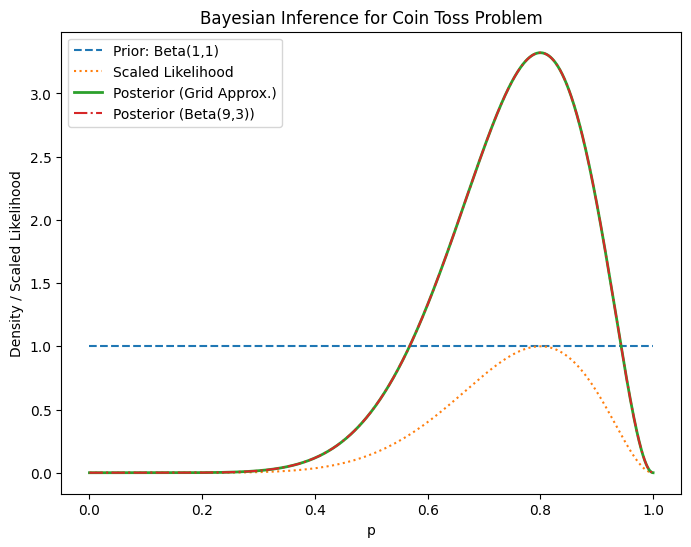

In [13]:
plt.figure(figsize=(8,6))
plt.plot(p_grid, prior, label="Prior: Beta(1,1)", linestyle='--')
plt.plot(p_grid, likelihood/np.max(likelihood), label="Scaled Likelihood", linestyle=':')
plt.plot(p_grid, posterior, label="Posterior (Grid Approx.)", linewidth=2)
plt.plot(p_grid, posterior_analytical, label="Posterior (Beta(9,3))", linestyle='-.')
plt.xlabel("p")
plt.ylabel("Density / Scaled Likelihood")
plt.legend()
plt.title("Bayesian Inference for Coin Toss Problem")
plt.show()

### **b. Đồng xu có khả năng cân đối cao ($p$ quanh $0.5$)**

Vì đồng xu có khả năng cân đối cao ($p$ quanh $0.5$), nghĩa là trong $\mathcal{k}$ lần tung thì có $a$ lần là mặt ngửa và $b$ lần là mặt xắp sao cho $\frac{a}{a + b} \approx \frac{1}{2} \Rightarrow a \approx b$.

Ở trường hợp này, ta chọn phân phối tiên nghiệm cho $p$ là $Beta(a, a)$

Giả sử, ta chọn $a = 5$, thì $p \sim Beta(5, 5)$. Ta có:
$$
P(p; 5, 5) \propto p^{4}(1 - p)^{4}
$$

Từ công thức Bayes, $p$ có phân phối hậu nghiệm sau khi quan sát dữ liệu $D$ là:
$$
\begin{align*}
&P(p | D) \propto P(D | p) \; P(p; 5, 5)  \\

\Rightarrow \;
&P(p | D) \propto p^8(1 - p)^2 \times p^{4}(1 - p)^{4} \\

\Rightarrow \;
&P(p | D) \propto p^{12} (1 - p)^{6}

\end{align*}
$$

Nhận xét, $(p, D) \sim Beta(a + z, b + n - z)$

$\Rightarrow$ Phân phối hậu nghiệm: $(p, D) \sim Beta(13, 7)$

Phân phối $Beta(13, 7)$ có hàm mật độ được định nghĩa như sau:
$$
f(x, 13, 7) = \frac{x^{12}(1 - x)^{6}}{B(13, 7)}
$$

trong đó hàm $B(13, 7)$ được tính bằng:
$$
B(13, 7) = \int_0^1 t^{12}(1 - t)^{6} = \frac{\Gamma{(13)} \Gamma{(7)}}{\Gamma{(20)}} = \frac{1}{352716}
$$

$\Rightarrow f(x, 13, 7) = 352716 \times x^{12}(1 - x)^6$

Phân phối tiên nghiệm $p \sim Beta(5, 5)$ có kỳ vọng:
$$
E(p) = \frac{a}{a + b} = \frac{1}{2} = 0.5
$$

Hàm hợp lý từ dữ liệu $L(p | D) = P(D | p) = p^8 (1 - p)^{2}$ đạt cực đại tại
$$
\hat{p}_{\text{MLE}} = \frac{z}{n} = \frac{8}{10} = 0.8,
$$


- Kỳ vọng của phân phối hậu nghiệm: $(p, D) \sim Beta(13, 7)$: 
$$
E(p|D) = \frac{a + z}{a + z + b + n − z} = \frac{13}{20} = 0.65
$$

In [14]:
p_grid = np.linspace(0, 1, 1000)

# Tiên nghiệm
prior = p_grid**(5-1) * (1 - p_grid)**(5-1)
prior = prior / np.trapz(prior, p_grid)

likelihood = p_grid**8 * (1 - p_grid)**2

# Hậu nghiệm
unnorm_posterior = likelihood * prior
posterior = unnorm_posterior / np.trapz(unnorm_posterior, p_grid)

posterior_analytical = 352716 * p_grid**12 * (1 - p_grid)**6 

posterior_mean = np.trapz(p_grid * posterior, p_grid)

In [15]:
print("Kỳ vọng của phân phối tiên nghiệm (Beta(5,5)) :", 0.5)
print("MLE (z/n):", 0.8)
print("Kỳ vọng của phân phối hậu nghiệm:", posterior_mean)

Kỳ vọng của phân phối tiên nghiệm (Beta(5,5)) : 0.5
MLE (z/n): 0.8
Kỳ vọng của phân phối hậu nghiệm: 0.6500000000000001


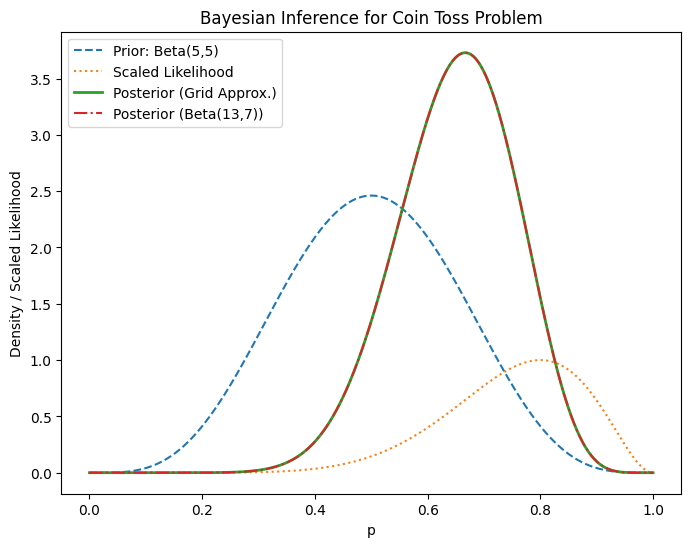

In [16]:
plt.figure(figsize=(8,6))
plt.plot(p_grid, prior, label="Prior: Beta(5,5)", linestyle='--')
plt.plot(p_grid, likelihood/np.max(likelihood), label="Scaled Likelihood", linestyle=':')
plt.plot(p_grid, posterior, label="Posterior (Grid Approx.)", linewidth=2)
plt.plot(p_grid, posterior_analytical, label="Posterior (Beta(13,7))", linestyle='-.')
plt.xlabel("p")
plt.ylabel("Density / Scaled Likelihood")
plt.legend()
plt.title("Bayesian Inference for Coin Toss Problem")
plt.show()

### **c. Đồng xu có khả năng mất cân đối cao ($p$ quanh $0$ hoặc $1$).**

Vì đồng xu có khả mất cân đối cao, thì phân phối tiên nghiệm cho $p$ là $Beta(0.5, 0.5)$. Ta có:
$$
P(p; 0.5, 0.5) \propto p^{-0.5}(1 - p)^{-0.5}
$$

Từ công thức Bayes, $p$ có phân phối hậy nghiệm sau khi quan sát dữ liệu $D$ là:
$$
\begin{align*}
&P(p | D) \propto P(D | p) \; P(p; 0.5, 0.5)  \\

\Rightarrow \;
&P(p | D) \propto p^8(1 - p)^2 \times p^{-0.5}(1 - p)^{-0.5} \\

\Rightarrow \;
&P(p | D) \propto p^{7.5} (1 - p)^{1.5}


\end{align*}
$$

Nhận xét, $(p, D) \sim Beta(a + z, b + n - z)$

$\Rightarrow$ Phân phối hậu nghiệm: $(p, D) \sim Beta(8.5, 2.5)$

Phân phối $Beta(8.5, 2.5)$ có hàm mật độ được định nghĩa như sau:
$$
f(x, 8.5, 2.5) = \frac{x^{7.5}(1 - x)^{1.5}}{B(8.5, 2.5)}
$$

Phân phối tiên nghiệm $p \sim Beta(0.5, 0.5)$ có kỳ vọng:
$$
E(p) = \frac{a}{a + b} = \frac{1}{2} = 0.5
$$

Hàm hợp lý từ dữ liệu $L(p | D) = P(D | p) = p^8 (1 - p)^{2}$ đạt cực đại tại
$$
\hat{p}_{\text{MLE}} = \frac{z}{n} = \frac{8}{10} = 0.8,
$$


- Kỳ vọng của phân phối hậu nghiệm: $(p, D) \sim Beta(8.5, 2.5)$:
$$
E(p|D) = \frac{a + z}{a + z + b + n − z} = \frac{8.5}{11} \approx 0.7(72)
$$

In [17]:
from scipy.special import beta as beta_func

p_grid = np.linspace(1e-6, 1-1e-6, 1000)

# Tiên nghiệm
prior = p_grid**(-0.5) * (1 - p_grid)**(-0.5)
prior = prior / np.trapz(prior, p_grid)

likelihood = p_grid**8 * (1 - p_grid)**2

# Hậu nghiệm
unnorm_posterior = likelihood * prior
posterior = unnorm_posterior / np.trapz(unnorm_posterior, p_grid)

posterior_analytical = (p_grid**(8.5-1) * (1-p_grid)**(2.5-1)) / beta_func(8.5,2.5)

posterior_mean = np.trapz(p_grid * posterior, p_grid)

In [18]:
print("Kỳ vọng của phân phối tiên nghiệm (Beta(0.5,0.5)) :", 0.5)
print("MLE (z/n):", 0.8)
print("Kỳ vọng của phân phối hậu nghiệm:", posterior_mean)

Kỳ vọng của phân phối tiên nghiệm (Beta(0.5,0.5)) : 0.5
MLE (z/n): 0.8
Kỳ vọng của phân phối hậu nghiệm: 0.7727272364561827


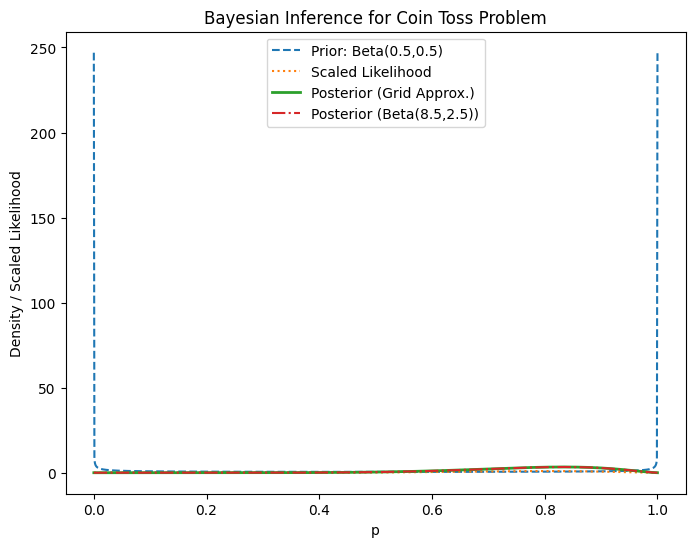

In [19]:
plt.figure(figsize=(8,6))
plt.plot(p_grid, prior, label="Prior: Beta(0.5,0.5)", linestyle='--')
plt.plot(p_grid, likelihood/np.max(likelihood), label="Scaled Likelihood", linestyle=':')
plt.plot(p_grid, posterior, label="Posterior (Grid Approx.)", linewidth=2)
plt.plot(p_grid, posterior_analytical, label="Posterior (Beta(8.5,2.5))", linestyle='-.')
plt.xlabel("p")
plt.ylabel("Density / Scaled Likelihood")
plt.legend()
plt.title("Bayesian Inference for Coin Toss Problem")
plt.show()

### **d. $p$ chỉ có thể nhận 1 trong 3 giá trị: $0.2, 0.7, 0.9$.**

Vì $p$ không ưu tiên bất kì giá trị nào trong 3 giá trị %0.2, 0.7, 0.9% nên ta chọn tiên nghiệm đồng đều cho cả 3 giá trị này:
$$
P(p = 0.2) = P(p = 0.7) = P(p = 0.9) = \frac{1}{3}
$$

Tính giá trị của hàm hợp lý cho từng $p$:

- Với $p = 0.2$:
$$
L(0.2) \propto 0.2^8 \times (1 - 0.2)^2 = 0.2^8 \times 0.8^2 \approx 1.6384 \times 10^{-6}
$$

- Với $p = 0.7$:
$$
L(0.7) \propto 0.7^8 \times (1 - 0.7)^2 = 0.7^8 \times 0.3^2 \approx 0.0051883
$$

- Với $p = 0.9$:
$$
L(0.9) \propto 0.9^8 \times (1 - 0.9)^2 = 0.9^8 \times 0.1^2 \approx 0.0043047
$$


Từ công thức Bayes, ta có:

$$
P(p | D) \propto P(D | p) \, P(p).
$$

Với tiên nghiệm đồng nhất $P(p) = \frac{1}{3}$, ta có:

- Với $p = 0.2$:
$$
\tilde{P}(0.2) = \frac{1}{3} \times 1.6384 \times 10^{-6} \approx 5.4613 \times 10^{-7}
$$

- Với $p = 0.7$:
$$
\tilde{P}(0.7) = \frac{1}{3} \times 0.0051883 \approx 0.00172944
$$

- Với $p = 0.9$:
$$
\tilde{P}(0.9) = \frac{1}{3} \times 0.0043047 \approx 0.0014349
$$


Ta có tổng các giá trị chưa chuẩn hóa:

$$
S = 5.4613 \times 10^{-7} + 0.00172944 + 0.0014349 \approx 0.00316488
$$

Phân phối hậu nghiệm theo công thức Bayes:

- $P(p = 0.2 | D) = \dfrac{5.4613 \times 10^{-7}}{0.00316488} \approx 0.00017$ 

- $P(p = 0.7 | D) = \dfrac{0.00172944}{0.00316488} \approx 0.5467$ 

- $P(p = 0.9 | D) = \dfrac{0.0014349}{0.00316488} \approx 0.4533$


- Kỳ vọng của phân phối hậu nghiệm:
$$
\begin{align*}

E(p | D) &= 0.2 \times 0.00017 + 0.7 \times 0.5467 + 0.9 \times 0.4533 \\
&\approx 0.000034 + 0.38269 + 0.40797 \approx 0.7907.

\end{align*}
$$


In [20]:
p_values = np.array([0.2, 0.7, 0.9])

# Tiên nghiệm
prior = np.ones(3) / 3

likelihood = p_values**8 * (1 - p_values)**2

# Hậu nghiệm
unnorm_posterior = likelihood * prior
posterior = unnorm_posterior / np.sum(unnorm_posterior)

posterior_mean = np.sum(p_values * posterior)


In [21]:
print("Các giá trị của p:", p_values)
print("Tiên nghiệm:", prior)
print("Likelihood:", likelihood)
print("Posterior chưa chuẩn hóa:", unnorm_posterior)
print("Phân phối hậu nghiệm:", posterior)
print("Kỳ vọng của phân phối hậu nghiệm:", posterior_mean)

Các giá trị của p: [0.2 0.7 0.9]
Tiên nghiệm: [0.33333333 0.33333333 0.33333333]
Likelihood: [1.6384000e-06 5.1883209e-03 4.3046721e-03]
Posterior chưa chuẩn hóa: [5.46133333e-07 1.72944030e-03 1.43489070e-03]
Phân phối hậu nghiệm: [1.72560675e-04 5.46447848e-01 4.53379591e-01]
Kỳ vọng của phân phối hậu nghiệm: 0.7905896378452353


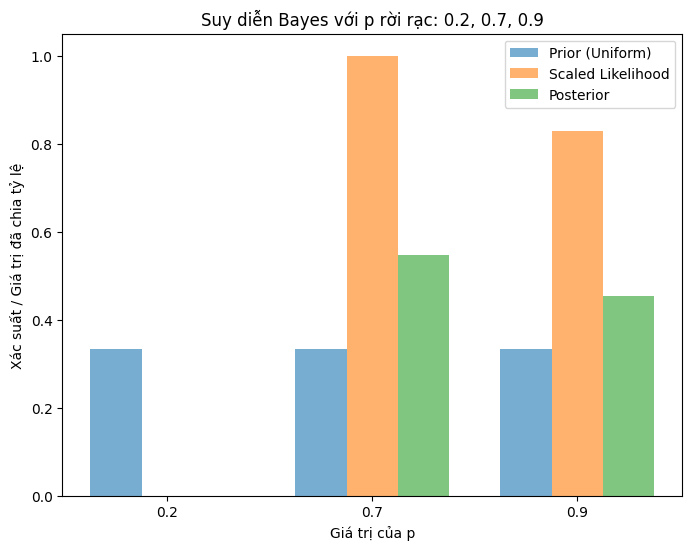

In [22]:
scaled_likelihood = likelihood / np.max(likelihood)

indices = np.arange(len(p_values))
width = 0.25

plt.figure(figsize=(8,6))
plt.bar(indices - width, prior, width, label="Prior (Uniform)", alpha=0.6)
plt.bar(indices, scaled_likelihood, width, label="Scaled Likelihood", alpha=0.6)
plt.bar(indices + width, posterior, width, label="Posterior", alpha=0.6)

plt.xticks(indices, [str(p) for p in p_values])
plt.xlabel("Giá trị của p")
plt.ylabel("Xác suất / Giá trị đã chia tỷ lệ")
plt.title("Suy diễn Bayes với p rời rạc: 0.2, 0.7, 0.9")
plt.legend()
plt.show()

### **e. $0.4 \le 𝑝 \le 0.9$**

Vì $0.4 \le p \le 0.9$, $p$ ngẫu nhiên liên tục trên đoạn $[0.4. 0.9]$ ,thì phân phối tiên nghiệm cho p sẽ là phân phối đều trên đoạn $[0.4. 0.9]$, ký hiệu: $p \sim \mathcal{U}(0.4, 0.9)$

Khi đó hàm mật độ tiên nghiệm của $p$ có dạng:
$$
f(p) = 
\begin{cases}
\frac{1}{0.9 - 0.4}, & 0.4 \le p \le 0.9 \\
0, & \text{khác}

\end{cases}
$$

hay

$$
f(p) = 
\begin{cases}
2, & 0.4 \le p \le 0.9 \\
0, & \text{khác}

\end{cases}
$$


Hàm tiên nghiệm:
- Kỳ vọng:
$$
E(p) = \frac{a + b}{2} = 0.65
$$

- Phương sai:
$$
Var(p) = \frac{(b - a)^2}{12} \approx 0.0208(3)
$$

Từ công thức Bayes, $p$ có phân phối hậu nghiệm như sau:
$$

P(p|D) \propto P(D|p) \; f(p) = 2 \, p^8(1 - p)^2 \quad \text{với } 0.4 \le p \le 0.9
$$

Để có phân phối xác suất hợp lệ, ta cần tính hằng số chuẩn hóa:
$$
Z = \int_{0.4}^{0.9}  2 \, p^8(1 - p)^2 \, dp \approx 0.0036546
$$

$\Rightarrow$ Phân phối hậu nghiệm sau khi chuẩn hóa:
$$
f(p|D) = \frac{ 2 \, p^8(1 - p)^2}{Z} \approx 547.2555 \times p^8(1 - p)^2
$$

- Kỳ vọng của phân phối hậu nghiệm:
$$
E(p | D) = \int_{0.4}^{0.9} p \, f(p | D) \, dp 
= \frac{\int_{0.4}^{0.9} 2p^9 (1 - p)^2 \, dp}{Z} \approx \frac{0.00268581}{0.0036546} \approx 0.734912
$$

In [23]:
p_grid = np.linspace(0.4, 0.9, 1000)

prior = np.ones_like(p_grid) / (0.9 - 0.4)

likelihood = p_grid**8 * (1 - p_grid)**2

# Hậu nghiệm
unnorm_posterior = likelihood * prior
posterior = unnorm_posterior / np.trapz(unnorm_posterior, p_grid)

posterior_mean = np.trapz(p_grid * posterior, p_grid)

print("Kỳ vọng của phân phối hậu nghiệm:", posterior_mean)

Kỳ vọng của phân phối hậu nghiệm: 0.7349140835013506


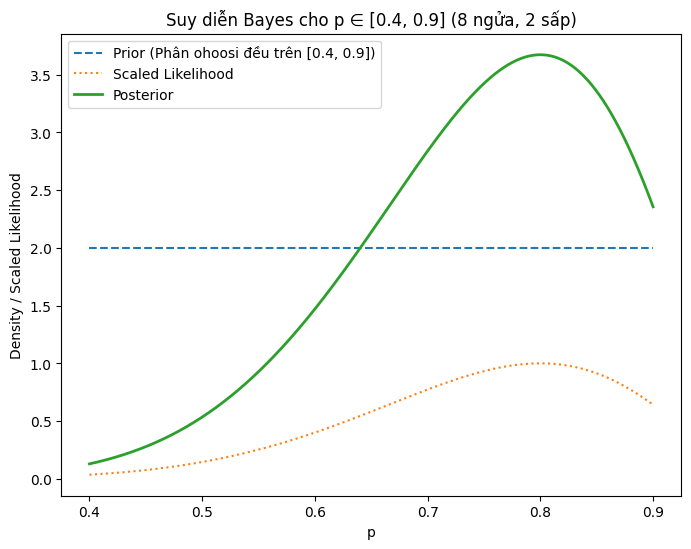

In [24]:
plt.figure(figsize=(8,6))
plt.plot(p_grid, prior, label='Prior (Phân ohoosi đều trên [0.4, 0.9])', linestyle='--')
plt.plot(p_grid, likelihood / np.max(likelihood), label='Scaled Likelihood', linestyle=':')
plt.plot(p_grid, posterior, label='Posterior', linewidth=2)
plt.xlabel("p")
plt.ylabel("Density / Scaled Likelihood")
plt.title("Suy diễn Bayes cho p ∈ [0.4, 0.9] (8 ngửa, 2 sấp)")
plt.legend()
plt.show()

$\Rightarrow$ Cả 5 trường hợp đều có kỳ vọng $p$ lớn hơn 0.6

---

## **Câu 3.**

Cho các biến ngẫu nhiên $X, Y, Z$ có phân phối như sau:
$$
X \sim \mathcal{N}(0, 2^2), \quad
Y \sim \mathcal{U}(0, |X|), \quad
Z \sim \mathcal{E}(1/Y)
$$

Trong đó,  $\mathcal{N}(\mu, \sigma^2)$ là phân phối chuẩn có kỳ vọng $\mu$ và phương sai $\sigma^2$, $\mathcal{U}(a, b)$ là phân phối đều trên khoảng $(a, b)$, $\mathcal{E}(\lambda)$ là phân phối mũ với kỳ vọng $1/\lambda$

Ước lượng xác suất $P(X \geq 3 \mid Z = 4)$

---

Hàm mật độ của từng biến:

- $X \sim \mathcal{N(0, 2^2)}$:
$$
f_X(x) = \frac{1}{2 \sqrt{2 \pi}} \times e^{-\frac{x^2}{8}}
$$

- $Y \sim \mathcal{U}(0, |X|)$: Cho $X = x, Y$ có phân phối đều trên $Y \sim \mathcal{U}(0, |x|)$
$$
f_{Y|X}(y|x) = 
\begin{cases} 

\frac{1}{|x|}, & \text{Nếu } 0 \le y \le |x| \\
0, & {Khác}

\end{cases}
$$

- $Z \sim \mathcal{E}(1/Y)$: Cho $Y = y, Z$ có phân phối mũ $Z \sim \mathcal{E}(\frac{1}{y}) $
$$
f_{Z | Y}(z | y) = 
\begin{cases}
\frac{1}{y} e^{-\frac{z}{y}}, &\text{Nếu } z \ge 0 \\
0, &\text{Khác}

\end{cases}
$$

Hàm mật độ chung của các biến ngẫu nhiên $(X, Y, Z)$:
$$
f_{X, Y, Z}(x, y, z) = f_X(x) \cdot f_{Y | X}(y | x) \cdot f_{Z | Y}(z | y)
$$

$$
\Rightarrow f_{X, Y, Z}(x, y, z) = \frac{1}{2 \sqrt{2 \pi}} \times e^{-\frac{x^2}{8}} \cdot \frac{1}{|x|} \cdot \frac{1}{y} e^{-\frac{z}{y}}
$$

$\quad$ Với $0 \le y \le |x|, z \ge 0$

Hàm mật độ chung của $(X, Z)$:
$$
f_{X, Z}(x, z) = \int_{0}^{|x|} f_{X, Y, Z}(x, y, z) \; dy
$$

$\quad$ Theo đề, ta có: $X \ge 3$, nên $x > 0 \Rightarrow |x| = x$
$$
f_{X, Z}(x, z) =  \frac{1}{2 \sqrt{2 \pi}} \times e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot \int_{0}^{x} \frac{1}{y} e^{-\frac{z}{y}} \; dy
$$

$\quad$ Với $z = 4$, ta có:
$$
f_{X, Z}(x, 4) =  \frac{1}{2 \sqrt{2 \pi}} \times e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot \int_{0}^{x} \frac{1}{y} e^{-\frac{4}{y}} \; dy
$$

$\quad$ Xét $I = \int_{0}^{x} \frac{1}{y} e^{-\frac{4}{y}} \; dy$

$\quad$ Đặt $u = \frac{4}{y} \Rightarrow y = \frac{4}{u} \Rightarrow dy = -\frac{4}{u^2}du$

$\quad\quad$ - Khi $y \to 0_{+}$ thì $u \to +\infty$  
$\quad\quad$ - Khi $y = x$ thì $u = \frac{4}{x}$

$$
\begin{align*}
\Rightarrow I(x) 
&= \int_{+\infty}^{4/x} \frac{u}{4} \cdot e^{-u} \cdot (-\frac{4}{u^2}) \; du \\

&= -\int_{+\infty}^{4/x} \frac{e^{-u}}{u} \; du \\

&= \int_{4/x}^{+\infty} \frac{e^{-u}}{u} \; du \\

\end{align*}
$$

$\quad$ Để ý , đây là hàm tích phân mũ:
$$
I(x) = E_1(\frac{4}{x}) = \int_{4/x}^{+\infty} \frac{e^{-u}}{u} \; du
$$

$$
\Rightarrow f_{X, Z}(x, 4) =  \frac{1}{2 \sqrt{2 \pi}} \times e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot E_1(\frac{4}{x})

$$

Hàm mật độ của $Z$ tại giá trị $z = 4$:
$$
f_Z(4) = \int_{-\infty}^{+\infty} f_{X, Z}(x, 4) \; dx
$$

Do $f_X(x)$ đối xứng và tích phân $I(x)$ chỉ phụ thuộc vào $|x|$ nên:
$$
f_Z(4) = 2 \cdot \int_{0}^{+\infty} f_{X, Z}(x, 4) \; dx = 2 \cdot \int_{0}^{+\infty} \frac{1}{2 \sqrt{2 \pi}} \times e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot E_1(\frac{4}{x}) \; dx \\
$$

$$
\Rightarrow f_Z(4) = \frac{1}{\sqrt{2 \pi}} \times \int_{0}^{+\infty} e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot E_1(\frac{4}{x}) \; dx \\
$$

Xác suất có điều kiện $P(X \ge 3 | Z = 4)$:
$$
P(X \ge 3 | Z = 4) = \frac{\int_{3}^{+\infty} f_{X, Z}(x, 4) \; dx}{f_Z(4)}
$$

$$
\Rightarrow 
P(X \ge 3 | Z = 4) = \frac{\int_{3}^{+\infty} e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot E_1(\frac{4}{x}) \; dx }{2 \cdot \int_{0}^{+\infty} e^{-\frac{x^2}{8}} \cdot \frac{1}{x} \cdot E_1(\frac{4}{x}) \; dx }
$$

In [25]:
N = 10**6

# X ~ N(0, 2^2)
X = np.random.normal(0, 2, size=N)

# Y ~ U(0, |X|)
Y = np.random.uniform(0, np.abs(X))

# Tính (1/Y) exp(-4/Y)
eps = 1e-12  # tránh chia cho 0
w = np.where(Y > eps, (1/Y)*np.exp(-4/Y), 0)

# 4. Ước lượng P(X>=3|Z=4) = E[1_{X>=3} * w] / E[w]
numerator = np.sum((X >= 3) * w)
denom = np.sum(w)
estimate = numerator / denom

print("Ước lượng P(X>=3|Z=4) =", estimate)

Ước lượng P(X>=3|Z=4) = 0.20359242643681186


---

## **Câu 4.**

Tìm hiểu bộ dữ liệu Auto MPG tại
https://archive.ics.uci.edu/ml/datasets/Auto+MPG. Download tập tin dữ liệu auto-mpg.data(https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data). Dùng suy diễn Bayes để so sánh công suất mpg (miles per gallon) của các xe theo vùng sản xuất origin (American, European, Japanese) dùng các mô hình sau:  
a. Các nhóm riêng rẽ với phân phối chuẩn.  
b. Các nhóm riêng rẽ với phân phối Student (kháng ngoại lai).  
c. Mô hình phân cấp (“chia sẻ thông tin nhóm”) với phân phối Student

----

In [26]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [27]:
col_names = ["mpg", "cylinders", "displacement", "horsepower", 
             "weight", "acceleration", "model_year", "origin", "car_name"]

data = pd.read_csv("auto-mpg.data", delim_whitespace=True, names=col_names, na_values='?')
data = data.dropna()

data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car_name      392 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 30.6+ KB


In [29]:
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [30]:
data["horsepower"] = data["horsepower"].astype(float)

# Chuyển đổi cột origin từ số thành tên vùng sản xuất
origin_mapping = {1: "American", 2: "European", 3: "Japanese"}
data["origin_name"] = data["origin"].map(origin_mapping)

groups = data.groupby("origin_name")

---

### **a. Các nhóm riêng rẽ với phân phối chuẩn.**

Giả sử với mỗi nhóm (ví dụ: theo vùng sản xuất), các quan sát $x_1, x_2, \dots, x_n$ được cho bởi mô hình:
$$
x_i \sim \mathcal{N}(\mu, \sigma^2), \quad \text{với } i = 1, 2, \dots, n.
$$

Ta có hàm mật độ xác suất:

$$
f(x_i \mid \mu, \sigma^2) = \frac{1}{\sqrt{2\pi \sigma^2}} e^{\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)}
$$

Với $n$ quan sát độc lập, hàm hợp lý (likelihood) cho toàn bộ dữ liệu $D = \{x_1, x_2, \dots, x_n\}$ là:

$$
L(\mu, \sigma^2 \mid D) = \prod_{i=1}^{n} f(x_i \mid \mu, \sigma^2)
= \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi \sigma^2}} e^{\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)}
$$


$$
\Rightarrow
L(\mu, \sigma^2 \mid D) = \left( \frac{1}{\sqrt{2\pi \sigma^2}} \right)^n e^{\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right)}
$$

$$
\Rightarrow
L(\mu, \sigma^2 \mid D) \propto (\sigma^2)^{-n/2} e^{\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right)}
$$

Hàm tiên nghiệm **Jeffreys prior**:

$$
p(\mu, \sigma^2) \propto \frac{1}{\sigma^2}
$$

Từ công thức Bayes, ta có phân phối hậu nghiệm như sau:

$$
p(\mu, \sigma^2 \mid D) \propto p(\mu, \sigma^2) \cdot L(\mu, \sigma^2 \mid D)
$$

$$
\Rightarrow
p(\mu, \sigma^2 \mid D) \propto \frac{1}{\sigma^2} \cdot (\sigma^2)^{-n/2} e^{\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right)}
$$

$$
\Rightarrow
p(\mu, \sigma^2 \mid D) \propto (\sigma^2)^{-(n/2 + 1)} e^{\left( -\frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2 \right)}
$$

Tích phân theo $\sigma^2$:

$$
p(\mu \mid D) = \int_0^\infty p(\mu, \sigma^2 \mid D) \, d\sigma^2
$$

Kết quả là:

$$
\mu \mid D \sim t_{n-1} \left( \bar{x}, \frac{s}{\sqrt{n}} \right)
$$

Trong đó:
- $\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$ là trung bình mẫu,
- $s$ là độ lệch chuẩn mẫu (unbiased),
- $t_{n-1}$ là phân phối Student-t với $n-1$ bậc tự do.

In [31]:
n_samples = 10000

post_samples = {}
group_stats = {}

for name, group in groups:
    n = len(group)
    mean_val = group["mpg"].mean()
    std_val = group["mpg"].std(ddof=1)
    group_stats[name] = {"n": n, "mean": mean_val, "std": std_val}
    
    # Scale cho Student-t: s/sqrt(n)
    scale = std_val / np.sqrt(n)
    df = n - 1  

    t_samples = np.random.standard_t(df, size=n_samples)
    samples = mean_val + scale * t_samples
    post_samples[name] = samples
    
    print(f"{name}: n = {n}, mean = {mean_val:.2f}, std = {std_val:.2f}")

American: n = 245, mean = 20.03, std = 6.44
European: n = 68, mean = 27.60, std = 6.58
Japanese: n = 79, mean = 30.45, std = 6.09


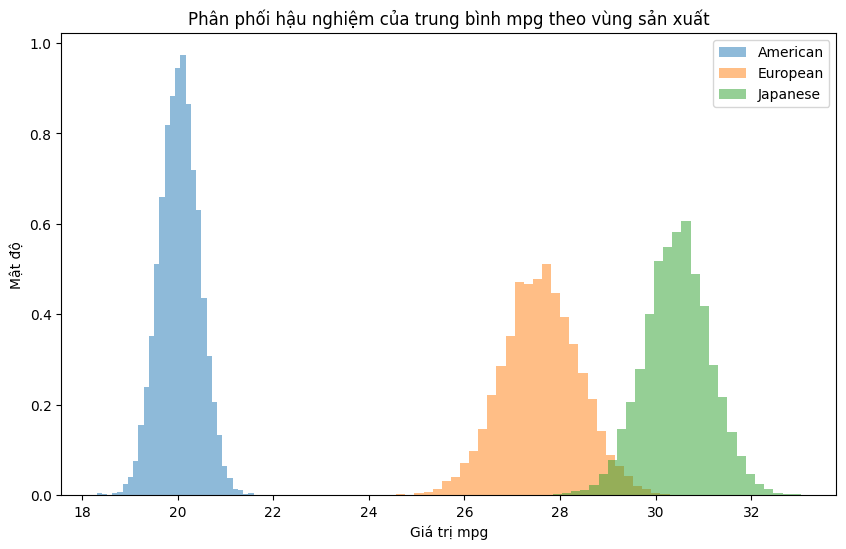

In [32]:
plt.figure(figsize=(10,6))
for name, samples in post_samples.items():
    plt.hist(samples, bins=30, alpha=0.5, density=True, label=name)
plt.xlabel("Giá trị mpg")
plt.ylabel("Mật độ")
plt.title("Phân phối hậu nghiệm của trung bình mpg theo vùng sản xuất")
plt.legend()
plt.show()

### **b. Các nhóm riêng rẽ với phân phối Student (kháng ngoại lai).**

In [33]:
def student_t_pdf(x, mu, sigma, nu):
    num = math.gamma((nu+1)/2)
    den = math.gamma(nu/2) * np.sqrt(nu*np.pi) * sigma
    return num/den * (1 + ((x-mu)/sigma)**2/nu)**(-(nu+1)/2)

n_samples = 10000   
n_grid = 200        
nu = 3              # Số bậc tự do cho Student-t 

post_samples_b = {}   
group_stats = {}      
for name, group in groups:
    xs = group["mpg"].values
    n = len(xs)
    # Ước lượng robust: dùng trung vị và MAD (median absolute deviation)
    mu_median = np.median(xs)
    mad = np.median(np.abs(xs - mu_median))
    sigma_robust = mad * 1.4826   # Hệ số chuyển đổi (cho phân phối chuẩn)
    group_stats[name] = {"n": n, "median": mu_median, "robust_sigma": sigma_robust}
    
    
    mu_grid = np.linspace(mu_median - 3*sigma_robust, mu_median + 3*sigma_robust, n_grid)
    
    # Tính log likelihood 
    log_lik = np.zeros(n_grid)
    for i, mu_val in enumerate(mu_grid):
        # Tính tổng log của mỗi giá trị
        log_lik[i] = np.sum(np.log([student_t_pdf(x, mu_val, sigma_robust, nu) for x in xs]))
    
    log_lik = log_lik - np.max(log_lik)
    lik = np.exp(log_lik)
    posterior = lik / np.sum(lik) 
    
    # Lấy mẫu từ lưới mu theo phân phối posterior đã tính
    samples = np.random.choice(mu_grid, size=n_samples, p=posterior)
    post_samples_b[name] = samples
    print(f"{name}: n = {n}, median = {mu_median:.2f}, robust_sigma = {sigma_robust:.2f}")

American: n = 245, median = 18.50, robust_sigma = 6.67
European: n = 68, median = 26.00, robust_sigma = 5.78
Japanese: n = 79, median = 31.60, robust_sigma = 6.52


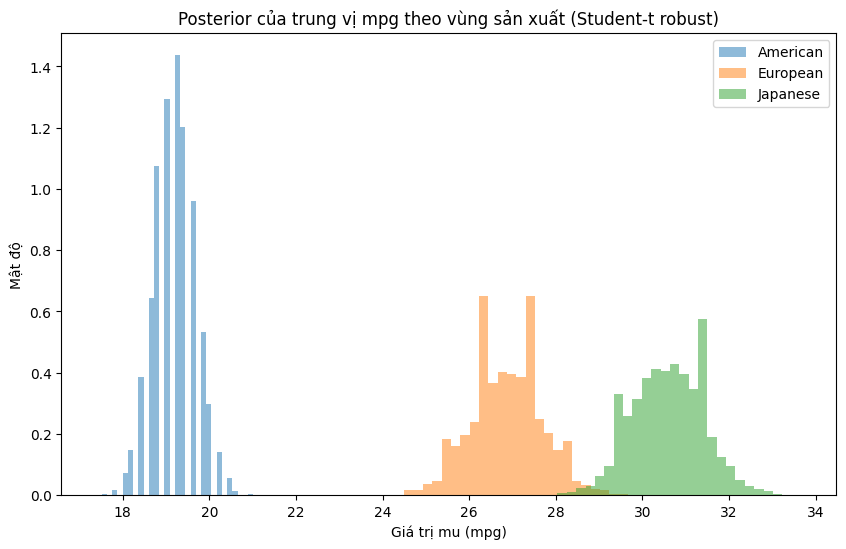

In [34]:
plt.figure(figsize=(10,6))
for name, samples in post_samples_b.items():
    plt.hist(samples, bins=30, alpha=0.5, density=True, label=name)
plt.xlabel("Giá trị mu (mpg)")
plt.ylabel("Mật độ")
plt.title("Posterior của trung vị mpg theo vùng sản xuất (Student-t robust)")
plt.legend()
plt.show()

### **c. Mô hình phân cấp (“chia sẻ thông tin nhóm”) với phân phối Student**

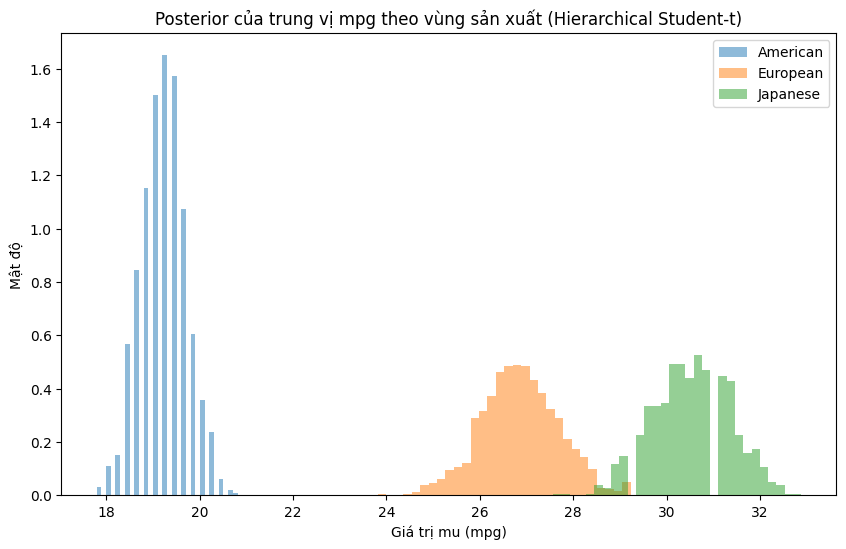

In [35]:
n_samples = 10000   # số mẫu lấy từ posterior (sau này dùng cho so sánh)
n_grid = 200        # số điểm trong grid của mu
nu = 3              # số bậc tự do cho likelihood

group_info = {}     # lưu lại các thông số robust (trung vị và robust sigma) cho từng nhóm
mu_grids = {}       # grid của mu cho mỗi nhóm
likelihoods = {}    # likelihood (chưa chuẩn hoá) trên lưới của mỗi nhóm

for name, group in groups:
    xs = group["mpg"].values
    n = len(xs)
    mu_median = np.median(xs)
    mad = np.median(np.abs(xs - mu_median))
    sigma_robust = mad * 1.4826   # chuyển đổi MAD thành ước lượng độ lệch chuẩn
    group_info[name] = {"n": n, "median": mu_median, "robust_sigma": sigma_robust}
    
    # Lưới cho mu: lấy xung quanh trung vị ± 3*sigma_robust
    mu_grid = np.linspace(mu_median - 3*sigma_robust, mu_median + 3*sigma_robust, n_grid)
    mu_grids[name] = mu_grid
    
    log_lik = np.zeros(n_grid)
    for i, mu_val in enumerate(mu_grid):
        # Tổng log-likelihood của các quan sát trong nhóm với tham số mu_val
        log_lik[i] = np.sum(np.log([student_t_pdf(x, mu_val, sigma_robust, nu) for x in xs]))
    # Tránh số quá lớn: chuẩn hoá log-likelihood
    log_lik = log_lik - np.max(log_lik)
    lik = np.exp(log_lik)
    likelihoods[name] = lik

#---------------------------
# Phần 2: Xây dựng mô hình phân cấp
# Giả sử các trung vị của các nhóm, μ_i, được sinh từ phân phối Student-t chung:
#     μ_i ~ Student_t(νₕ, μ₀, τ)
nu_h = 3  # số bậc tự do cho hyperprior

def student_t_pdf_h(mu, mu0, tau, nu_h):
    num = math.gamma((nu_h+1)/2)
    den = math.gamma(nu_h/2) * np.sqrt(nu_h*np.pi) * tau
    return num/den * (1 + ((mu-mu0)/tau)**2/nu_h)**(-(nu_h+1)/2)

# Xác định lưới cho hyperparameters: μ₀ và τ.
# Với μ₀: chọn khoảng bao phủ các trung vị của các nhóm
medians = [group_info[name]["median"] for name in group_info]
mu0_min = min(medians) - 5
mu0_max = max(medians) + 5
mu0_grid = np.linspace(mu0_min, mu0_max, 100)

# Với τ: chọn khoảng từ một giá trị nhỏ đến một giá trị đủ lớn để bao phủ sự khác biệt giữa các trung vị
tau_grid = np.linspace(0.1, 10, 100)

# Giả sử hyperprior cho μ₀ và τ là phẳng (uniform)
# Tính posterior cho hyperparameters dựa trên tích của tích phân (likelihood * prior của mỗi nhóm)
posterior_hyper = np.zeros((len(mu0_grid), len(tau_grid)))
for i, mu0 in enumerate(mu0_grid):
    for j, tau in enumerate(tau_grid):
        prod_integral = 1.0
        # Với mỗi nhóm, tích phân trên lưới μ của (likelihood của nhóm * prior của μ theo hyperparameters)
        for name in groups.groups.keys():
            mu_grid = mu_grids[name]
            prior_vals = np.array([student_t_pdf_h(mu, mu0, tau, nu_h) for mu in mu_grid])
            integrand = likelihoods[name] * prior_vals
            integral = np.trapz(integrand, mu_grid)  # tích phân xấp xỉ theo phương pháp hình thang
            prod_integral *= integral
        posterior_hyper[i, j] = prod_integral

# Chuẩn hoá posterior cho hyperparameters
posterior_hyper = posterior_hyper / np.sum(posterior_hyper)

#---------------------------
# Lấy mẫu từ posterior hyperparameters (μ₀, τ)
n_hyper_samples = 1000
mu0_samples = []
tau_samples = []
flat_posterior = posterior_hyper.flatten()
indices = np.arange(flat_posterior.size)
sampled_indices = np.random.choice(indices, size=n_hyper_samples, p=flat_posterior)
for idx in sampled_indices:
    i = idx // len(tau_grid)
    j = idx % len(tau_grid)
    mu0_samples.append(mu0_grid[i])
    tau_samples.append(tau_grid[j])
mu0_samples = np.array(mu0_samples)
tau_samples = np.array(tau_samples)

#---------------------------
# Với mỗi mẫu hyperparameter, ta sẽ lấy mẫu trung vị của từng nhóm theo posterior:
#     posterior của μ (cho nhóm i) ∝ likelihood(μ; dữ liệu nhóm i) * student_t_pdf_h(μ; μ₀, τ, νₕ)
hierarchical_samples = {name: [] for name in groups.groups.keys()}
for k in range(n_hyper_samples):
    mu0_k = mu0_samples[k]
    tau_k = tau_samples[k]
    for name in groups.groups.keys():
        mu_grid = mu_grids[name]
        prior_vals = np.array([student_t_pdf_h(mu, mu0_k, tau_k, nu_h) for mu in mu_grid])
        posterior_mu = likelihoods[name] * prior_vals
        posterior_mu = posterior_mu / np.sum(posterior_mu)
        # Lấy mẫu một giá trị μ từ lưới theo phân phối posterior
        sampled_mu = np.random.choice(mu_grid, p=posterior_mu)
        hierarchical_samples[name].append(sampled_mu)

# Chuyển các mẫu về dạng numpy array để dễ vẽ biểu đồ
for name in hierarchical_samples:
    hierarchical_samples[name] = np.array(hierarchical_samples[name])

#---------------------------
# Vẽ histogram của các mẫu trung vị theo mô hình phân cấp
plt.figure(figsize=(10,6))
for name, samples in hierarchical_samples.items():
    plt.hist(samples, bins=30, alpha=0.5, density=True, label=name)
plt.xlabel("Giá trị mu (mpg)")
plt.ylabel("Mật độ")
plt.title("Posterior của trung vị mpg theo vùng sản xuất (Hierarchical Student-t)")
plt.legend()
plt.show()

---

## **NGUỒN THAM KHẢO**

**1.** Slide thầy Vũ Quốc Hoàng - Bài 2 Ôn tập biến ngẫu nhiên - Thống kê máy tính và ứng dụng  
**2.** Slide thầy Vũ Quốc Hoàng - Bài 3: Phương pháp Monte Carlo và sinh số ngẫu nhiên  
**3.** Slide thầy Vũ Quốc Hoàng - Bài 5: Giới thiệu và thống kê Bayes và Markov Chain Monte Carlo  
**4.** [Rejection sampling](https://en.wikipedia.org/wiki/Rejection_sampling)  
**5.** [Gaussian Mixture Model](https://phamdinhkhanh.github.io/deepai-book/ch_ml/index_GMM.html)  
**6.** [[Xác Suất] Một số phân phối phổ biến](https://dominhhai.github.io/vi/2017/10/prob-com-var/#2-2-ph%C3%A2n-ph%E1%BB%91i-chu%E1%BA%A9n-normal-distribution)  
**7.** [Wikipedia - Phân phối chuẩn nhiều chiều](https://vi.wikipedia.org/wiki/Ph%C3%A2n_ph%E1%BB%91i_chu%E1%BA%A9n_nhi%E1%BB%81u_chi%E1%BB%81u)  
**8.** [Metropolis-Hastings MCMC from Scratch in Python](https://exowanderer.medium.com/metropolis-hastings-mcmc-from-scratch-in-python-c21e53c485b7)  
**9.** [Implementing Gibbs Sampling in Python](https://mr-easy.github.io/2020-05-21-implementing-gibbs-sampling-in-python/)  
**10.** [Một số phân phối liên tục thông dụng](https://www.studocu.vn/vn/document/truong-dai-hoc-kinh-te-thanh-pho-ho-chi-minh/xac-suat-thong-ke/chuong-4-gvfhfgf7gi/80828955)  
**11.** [Beta distribution](https://en.wikipedia.org/wiki/Beta_distribution)  
**12.** [Gamma function](https://en.wikipedia.org/wiki/Gamma_function)  
**13.** [Plausibility, The Beta Distribution, and Its Visualization](https://www.persuasivepython.com/5-plausvisualization)   
**14.** [Exponential integral](https://en.wikipedia.org/wiki/Exponential_integral)  
**15.** [Jeffreys prior for normal distribution with unknown mean and variance](https://stats.stackexchange.com/questions/156199/jeffreys-prior-for-normal-distribution-with-unknown-mean-and-variance)  

$$*****$$